# Proyecto 1: Protocolo E91 - Eavesdropping
**CC3050 - Tópicos en Computación: Computación Cuántica**

En este notebook simulamos en Qiskit el estado de Bell de Alice y Bob, y el estado que queda después de que un atacante lo "lee" con un qubit ancilla.

**Convención de qubits**

| Qubit | Quién es |
|---|---|
| `q0` | Alice |
| `q1` | Bob |
| `q2` | Atacante (ancilla) |

**Ojo:** Qiskit escribe los resultados al revés (little endian). La cadena `'01'` significa `q1=0, q0=1`.

**Cómo medimos en otras bases:** se rota el qubit antes de medir.

| Base | Rotación antes de medir |
|---|---|
| Z | ninguna |
| X | `H` |
| Y | `Sdg` y luego `H` |

## 0. Imports y funciones auxiliares

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

sim = AerSimulator()
SHOTS = 4096
BASES = ['Z', 'X', 'Y']

def rotar(qc, q, base):
    """Rota el qubit q para medir en la base indicada."""
    if base == 'X':
        qc.h(q)
    elif base == 'Y':
        qc.sdg(q)
        qc.h(q)
    # Z no necesita rotación

## Paso 1: Estado de Bell + mediciones de Alice y Bob en X, Y, Z

Construimos $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ con una `H` en Alice y un `CNOT` de Alice a Bob, y después medimos a los dos en cada base.

**Lo que esperamos** (según la sección 1.1 a mano):
- Z y X: solo `00` y `11`, más o menos 50/50 (correlación perfecta).
- Y: solo `01` y `10`, más o menos 50/50 (anticorrelación).
- Cada qubit por separado da 50/50 en las tres bases.

In [2]:
def bell(base):
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)          # |Φ+>
    qc.barrier()
    for q in (0, 1):
        rotar(qc, q, base)
    qc.measure([0, 1], [0, 1])
    return qc

resultados_bell = {}
for base in BASES:
    qc = bell(base)
    counts = sim.run(transpile(qc, sim), shots=SHOTS).result().get_counts()
    resultados_bell[base] = counts
    print(f"Base {base}: {counts}")

Base Z: {'11': 2019, '00': 2077}
Base X: {'11': 2054, '00': 2042}
Base Y: {'01': 2041, '10': 2055}


### Circuito del Bell (ejemplo en base X)

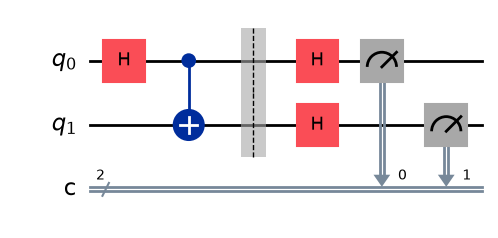

In [3]:
display(bell('X').draw('mpl'))

### Histogramas del Bell

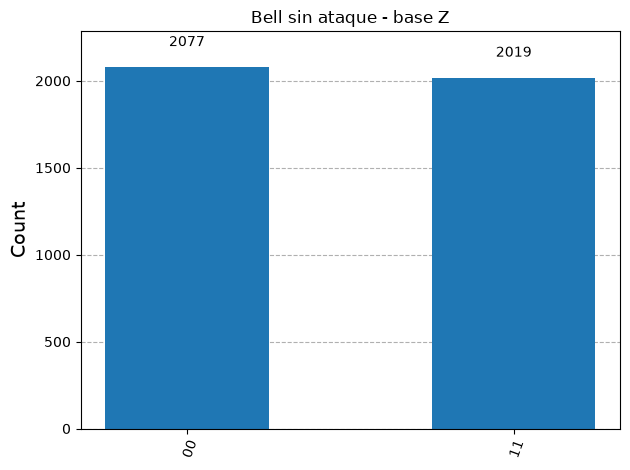

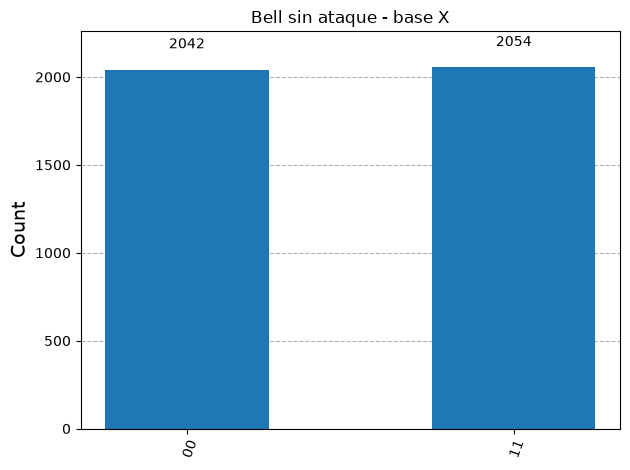

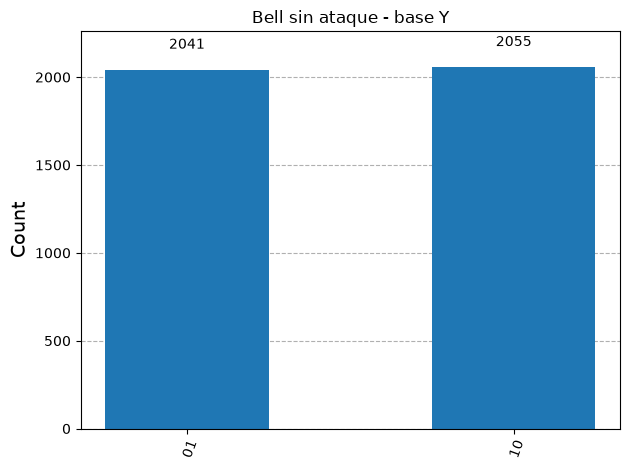

In [4]:
for base in BASES:
    display(plot_histogram(resultados_bell[base], title=f"Bell sin ataque - base {base}"))

## Paso 2: Estado después del ataque (GHZ + medición del atacante)

El atacante agrega una ancilla en $|0\rangle$ y le aplica un `CNOT` con control en Bob. Con eso el estado se vuelve el GHZ:

$$|\phi\rangle = \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$$

Después el atacante mide su qubit (proyección $P_v$ con $v=0,1$) y por último Alice y Bob miden en cada base. Usamos un registro clásico aparte para el atacante para poder separar los casos $v=0$ y $v=1$.

### 2.1 El estado GHZ (sin medir al atacante)

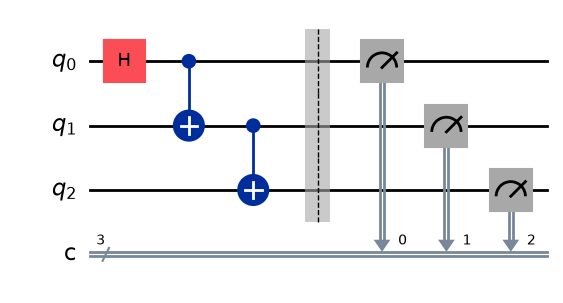

GHZ: {'111': 2075, '000': 2021}


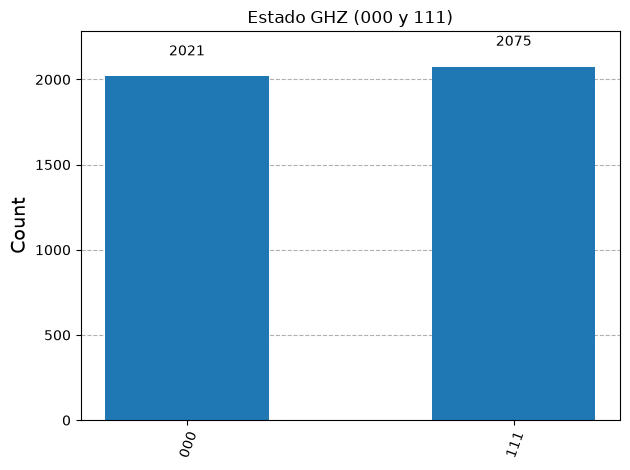

In [5]:
ghz = QuantumCircuit(3, 3)
ghz.h(0)
ghz.cx(0, 1)
ghz.cx(1, 2)
ghz.barrier()
ghz.measure([0, 1, 2], [0, 1, 2])

display(ghz.draw('mpl'))
counts_ghz = sim.run(transpile(ghz, sim), shots=SHOTS).result().get_counts()
print("GHZ:", counts_ghz)
display(plot_histogram(counts_ghz, title="Estado GHZ (000 y 111)"))

### 2.2 Circuito del ataque con medición del atacante

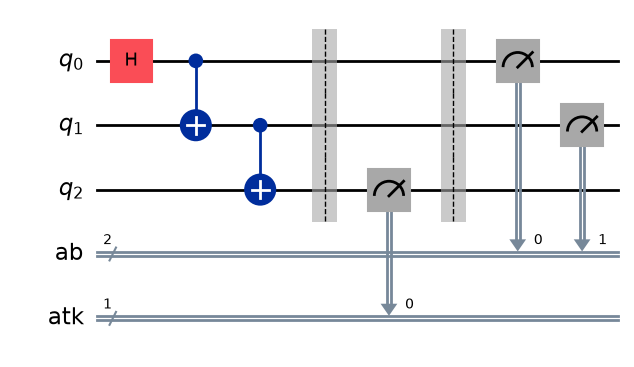

In [6]:
def ataque(base):
    q = QuantumRegister(3, 'q')
    ab = ClassicalRegister(2, 'ab')    # Alice y Bob
    atk = ClassicalRegister(1, 'atk')  # atacante
    qc = QuantumCircuit(q, ab, atk)

    qc.h(0)
    qc.cx(0, 1)          # Bell
    qc.cx(1, 2)          # CNOT con control en Bob y objetivo en la ancilla -> GHZ
    qc.barrier()
    qc.measure(2, atk[0])   # medición del atacante (P_v)
    qc.barrier()
    for i in (0, 1):
        rotar(qc, i, base)
    qc.measure([0, 1], ab)
    return qc

def correr_ataque(base):
    qc = ataque(base)
    counts = sim.run(transpile(qc, sim), shots=SHOTS).result().get_counts()
    # las llaves salen como 'atk ab', por ejemplo '0 00'
    v0 = {k.split()[1]: c for k, c in counts.items() if k.split()[0] == '0'}
    v1 = {k.split()[1]: c for k, c in counts.items() if k.split()[0] == '1'}
    return counts, v0, v1

display(ataque('Z').draw('mpl'))

### 2.3 Resultados del ataque en cada base

In [7]:
resultados_ataque = {}
for base in BASES:
    counts, v0, v1 = correr_ataque(base)
    resultados_ataque[base] = (counts, v0, v1)
    print(f"Base {base} | v=0: {v0} | v=1: {v1}")

Base Z | v=0: {'00': 2015} | v=1: {'11': 2081}
Base X | v=0: {'11': 540, '01': 506, '10': 503, '00': 515} | v=1: {'01': 518, '11': 502, '10': 530, '00': 482}
Base Y | v=0: {'01': 521, '11': 482, '00': 508, '10': 522} | v=1: {'00': 515, '10': 533, '01': 511, '11': 504}


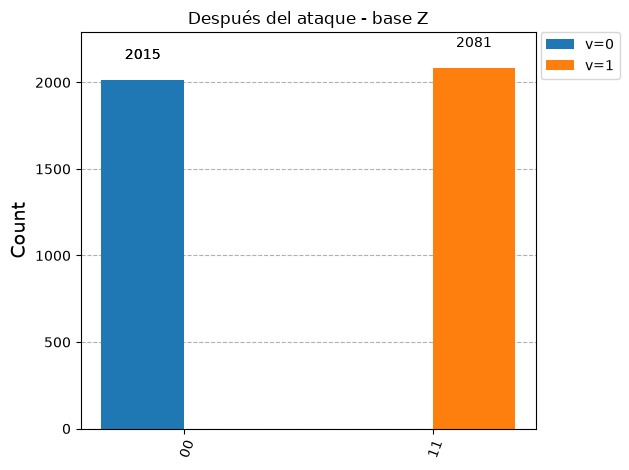

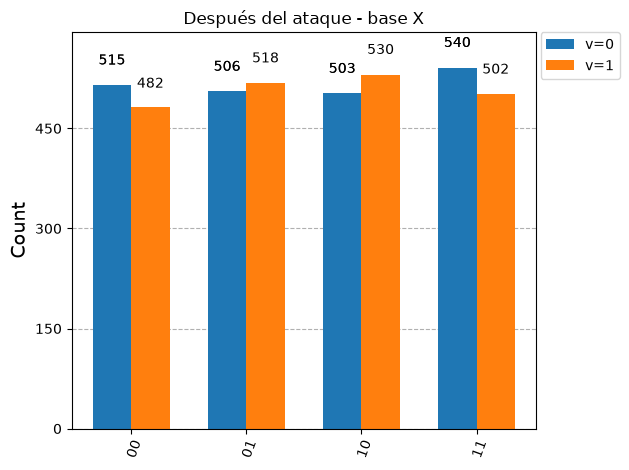

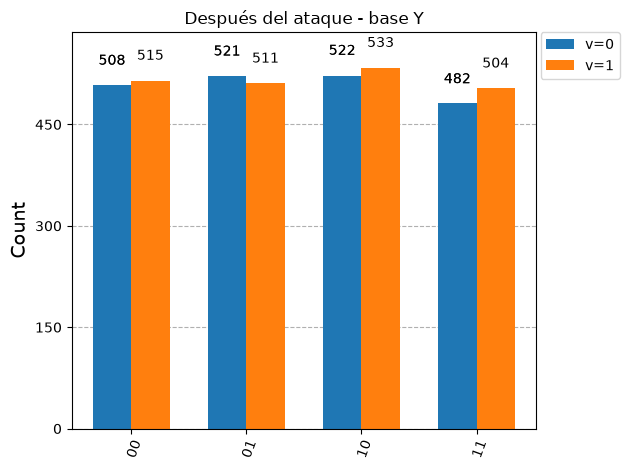

In [8]:
for base in BASES:
    _, v0, v1 = resultados_ataque[base]
    display(plot_histogram([v0, v1], legend=['v=0', 'v=1'], title=f"Después del ataque - base {base}"))

## Paso 3: Medición de Alice y Bob en Z y detección del ataque

**Pregunta:** ¿Por qué Alice y Bob pueden detectar el ataque?

Primero comparamos las probabilidades en Z con y sin ataque, y después medimos qué tan correlacionados quedan en cada base.

### 3.1 Comparación en la base Z

Z sin ataque: {'00': 0.507, '11': 0.493}
Z con ataque: {'00': 0.492, '11': 0.508}


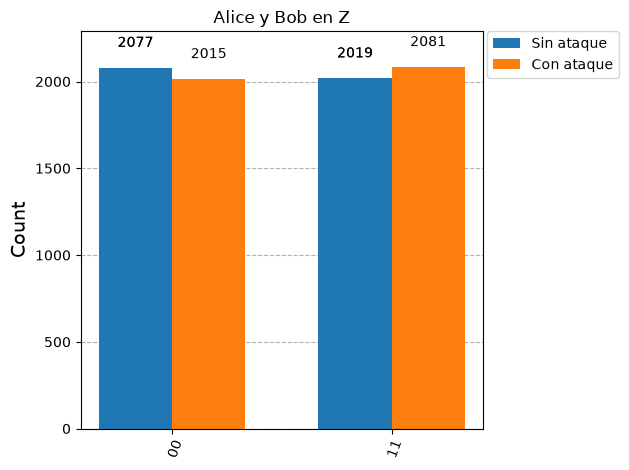

In [9]:
def a_probs(counts):
    total = sum(counts.values())
    return {k: round(v / total, 3) for k, v in sorted(counts.items())}

# Con ataque: juntamos v=0 y v=1 (Alice y Bob no saben cuánto leyó el atacante)
_, v0z, v1z = resultados_ataque['Z']
z_ataque = {}
for d in (v0z, v1z):
    for k, c in d.items():
        z_ataque[k] = z_ataque.get(k, 0) + c

print("Z sin ataque:", a_probs(resultados_bell['Z']))
print("Z con ataque:", a_probs(z_ataque))
display(plot_histogram([resultados_bell['Z'], z_ataque], legend=['Sin ataque', 'Con ataque'], title="Alice y Bob en Z"))

### 3.2 Tasa de error en cada base

Sin ataque, el Bell cumple una regla de paridad en cada base:
- Z y X: Alice y Bob obtienen el **mismo** resultado (paridad par: `00`, `11`).
- Y: obtienen resultados **distintos** (paridad impar: `01`, `10`).

La tasa de error es la fracción de corridas donde no se cumple esa regla. Si es 0 no pasa nada raro; si es distinta de 0, alguien tocó el estado.

In [10]:
paridad_esperada = {'Z': 0, 'X': 0, 'Y': 1}   # 0 = par, 1 = impar

def tasa_error(counts, base):
    total = sum(counts.values())
    malos = sum(c for k, c in counts.items() if k.count('1') % 2 != paridad_esperada[base])
    return malos / total

def juntar(v0, v1):
    out = dict(v0)
    for k, c in v1.items():
        out[k] = out.get(k, 0) + c
    return out

print(f"{'Base':<6}{'Sin ataque':>14}{'Con ataque':>14}")
for base in BASES:
    sin = tasa_error(resultados_bell[base], base)
    _, v0, v1 = resultados_ataque[base]
    con = tasa_error(juntar(v0, v1), base)
    print(f"{base:<6}{sin:>13.1%}{con:>14.1%}")

Base      Sin ataque    Con ataque
Z              0.0%          0.0%
X              0.0%         50.2%
Y              0.0%         49.0%


### Respuesta a la pregunta 3

**¿Por qué Alice y Bob pueden detectar el ataque?**

Si solo miran la base Z **no se dan cuenta**. Con el ataque siguen obteniendo `00` y `11` con probabilidad 1/2 cada uno, igual que con el Bell original, así que las probabilidades en Z se ven idénticas (por eso la pista del enunciado dice que no se percibe viendo solamente las probabilidades). Incluso el atacante queda perfectamente correlacionado con ellos: si lee `v=0`, Alice y Bob tienen `00`, y si lee `v=1`, tienen `11`.

La diferencia está en que el atacante **rompió el entrelazamiento**. Al medir la ancilla del GHZ, el estado colapsa a $|000\rangle$ o $|111\rangle$, o sea Alice y Bob quedan en $|00\rangle$ o $|11\rangle$, que son **estados producto** (se pueden escribir como $|0\rangle\otimes|0\rangle$ y $|1\rangle\otimes|1\rangle$). Ya no hay correlaciones cuánticas en las otras bases.

Eso se ve cuando miden en X o en Y:
- Sin ataque, en X siempre coinciden y en Y siempre son distintos (tasa de error 0%).
- Con ataque, los resultados de Alice y Bob salen independientes y aparecen los 4 resultados (`00`, `01`, `10`, `11`) con probabilidad ~1/4 cada uno. La tasa de error sube a ~50%, como se ve en la tabla de arriba.

Entonces, para detectar el ataque (que es la idea del protocolo E91), Alice y Bob eligen bases al azar, y después comparan públicamente una parte de sus resultados donde las bases son compatibles. Si encuentran errores en esas comparaciones, saben que el estado ya no es el Bell original y que hubo alguien espiando. Con un atacante que lee todos los qubits, el error de ~50% se nota con muy pocas comparaciones.